In [ ]:
# Objective

# A company is planning to launch a campaign for its new car brand and wants to analyze which customers are most likely to purchase the car.
# This analysis will help the company design advertisements that specifically target potential customers.
# To achieve this, the company consults a social network advertising company that provides data collected from a previous similar campaign.
# Using this data, a predictive model is constructed.
# The objective is to use Logistic Regression to predict whether a customer will purchase the car or not.

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
import pandas as pd
data = pd.read_csv("Purchase_data.csv")
print(data.head())


    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0


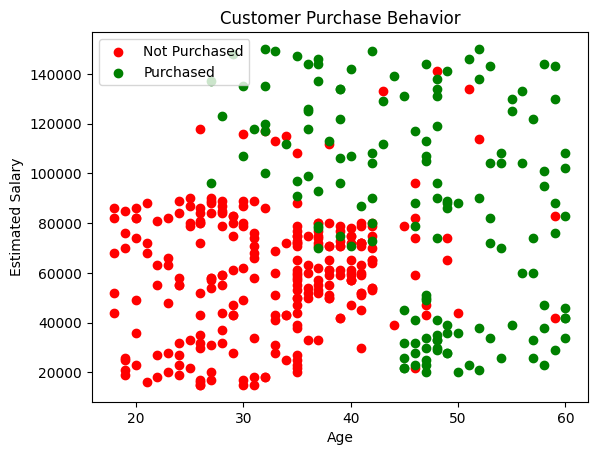

In [ ]:
import matplotlib.pyplot as plt


buyers = data[data['Purchased'] == 1]
non_buyers = data[data['Purchased'] == 0]

plt.scatter(non_buyers['Age'], non_buyers['EstimatedSalary'],
            color='red', label='Not Purchased')

plt.scatter(buyers['Age'], buyers['EstimatedSalary'],
            color='green', label='Purchased')

plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.title("Customer Purchase Behavior")
plt.legend()
plt.show()


In [ ]:
X=data.iloc[:,[2,3]].values
Y=data.iloc[:,4].values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.25, random_state=0
)

In [ ]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
classifier = LogisticRegression()
classifier.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred = classifier.predict(X_test)

In [ ]:
print(y_pred)

[0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0
 0 0 1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0
 0 0 1 0 1 1 1 1 0 0 1 1 0 1 0 0 0 1 0 0 0 0 0 0 1 1]


In [ ]:
import matplotlib.pyplot as plt

Confusion Matrix:
 [[65  3]
 [ 8 24]]


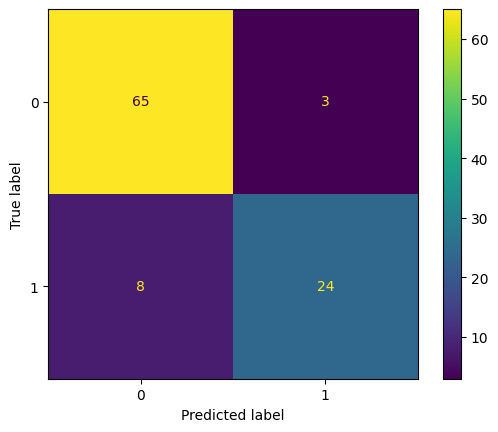

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()


# **Gradient decent method**

In [ ]:
X = data.iloc[:,[2,3]].values
Y = data.iloc[:,4].values

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.25, random_state=0
)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
import numpy as np

X_train_gd = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test_gd = np.c_[np.ones((X_test.shape[0], 1)), X_test]

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [ ]:
m, n = X_train_gd.shape

theta = np.zeros(n)

learning_rate = 0.01
iterations = 1000

In [ ]:
for i in range(iterations):

    z = X_train_gd.dot(theta)
    h = sigmoid(z)

    gradient = (1/m) * X_train_gd.T.dot(h - y_train)

    theta = theta - learning_rate * gradient

In [ ]:
z_test = X_test_gd.dot(theta)
probabilities = sigmoid(z_test)

y_pred_gd = (probabilities >= 0.5).astype(int)

In [ ]:
from sklearn.metrics import confusion_matrix

cm_gd = confusion_matrix(y_test, y_pred_gd)
print("Confusion Matrix (Gradient Descent):\n", cm_gd)

Confusion Matrix (Gradient Descent):
 [[66  2]
 [ 8 24]]


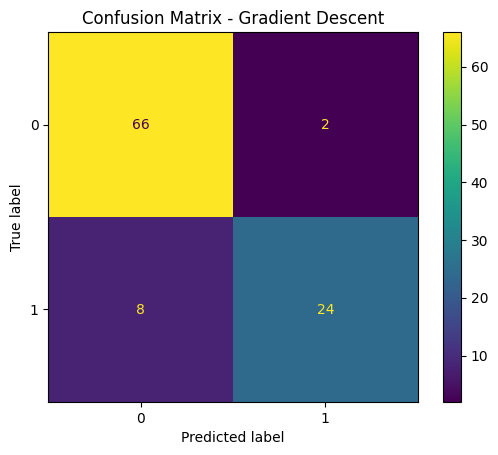

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_gd = confusion_matrix(y_test, y_pred_gd)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_gd)
disp.plot()

plt.title("Confusion Matrix - Gradient Descent")
plt.show()